<a href="https://colab.research.google.com/github/stavgrossfeld/analysis-portfolio/blob/main/Copy_of_ginkgo_hugging_face.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup and Authentication

In [1]:
from huggingface_hub import login
from google.colab import userdata

# Retrieve your token from the Secrets tab (the 🔑 icon)

HF_TOKEN = userdata.get('HF_TOKEN')
# Log in globally for the entire notebook session
login(token=HF_TOKEN, add_to_git_credential=True)

# 2. Data Loading (The Heavy Lifting) This downloads the 1.29GB parquet file and converts it to a Polars DataFrame.

In [2]:
from datasets import load_dataset

# Removing streaming=True downloads the file to local disk
ds_full = load_dataset(
    "ginkgo-datapoints/GDPx2",
    data_files="differential_expression.parquet",
    split="train",
    token=HF_TOKEN,
    streaming=False  # This is the key change
)

# After downloading, you can convert it directly to an Arrow table
arrow_table = ds_full.with_format("arrow").data.table

In [3]:
print(f"Total rows in ds_full: {len(ds_full):,}")

Total rows in ds_full: 40,768,764


In [4]:
import polars as pl

# Convert your existing Arrow table to a Polars DataFrame (Zero-copy)
df_pl = pl.from_arrow(arrow_table)

# Get the unique compounds as a list
compounds_list = df_pl.select("compound").unique().to_series().to_list()
print(compounds_list)

['Rotenone', 'DMH4', '(±)-alpha-Lipoic Acid', 'Triamterene', 'Furosemide', 'BRD3308', '5-(N-Ethyl-N-isopropyl)amiloride', 'CCT 018159', 'Alpelisib', 'Pyridostatin hydrochloride', 'Suprafenacine', 'Hydrocortisone', 'Ancitabine hydrochloride', 'LDC000067 hydrochloride', 'Beclomethasone', 'AMG-900', 'Alisertib', 'NVS-PAK1-1', 'Wortmannin from Penicillium funiculosum', 'Gemcitabine hydrochloride', 'Trichostatin A', 'Anisodamine', 'Pinacidil', 'Hypotaurine', 'Cevipabulin fumarate', 'Guanabenz acetate', 'Dabrafenib', 'Rigosertib', 'MPP+', 'Dexamethasone', 'erythro-9-(2-Hydroxy-3-nonyl)adenine hydrochloride', 'Panobinostat', 'Br-PBTC', 'Brefeldin-A', 'Thiocolchicine', 'Corticosterone', 'Calcimycin', 'Budesonide', 'RG2833', 'NG-Nitro-L-arginine', 'Rucaparib', 'Amsacrine hydrochloride', 'Nordihydroguaiaretic acid from Larrea divaricata (creosote bush)', 'Etoposide', 'Rufinamide', 'Colchicine', 'Betamethasone', 'Indibulin', 'Mitoxantrone', 'Idarubicin', 'Alclometasone dipropionate', 'Bortezomib'

# 3. Filtering and Preparation: Select your target compounds and genes, then slice the data.

In [5]:
target_compounds = [
    'Trichostatin A',     # High Response: Potent HDAC inhibitor (Positive Control)
    'Bortezomib',         # High Response: Proteasome inhibitor
    'Dexamethasone',      # Moderate/Baseline: Often used for steroid/hormone response
    'Hydrocortisone',     # Baseline: Similar to Dexamethasone, often stable
    'Colchicine',          # Specific Target: Mitotic inhibitor for cell cycle studies,
    'DMSO'
]

target_genes = ['GAPDH', 'ACTB', 'TOP2A']

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl

# Filter the Polars DataFrame using the target compounds and genes
df_genes_pl = df_pl.filter(
    pl.col("compound").is_in(target_compounds)
).filter(
    pl.col("gene").is_in(target_genes)
).select(
    "gene", "compound", "cell_line", "log2FoldChange"
)

# Convert the Polars DataFrame to a pandas DataFrame for seaborn
df_genes = df_genes_pl.to_pandas()

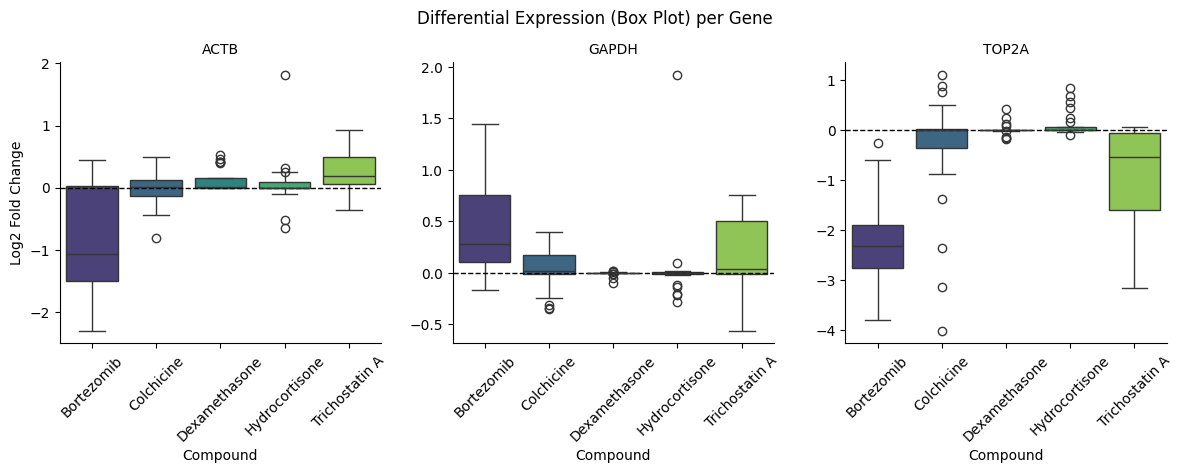

In [7]:
# Create a Faceted Plot with Box Plots
g = sns.FacetGrid(df_genes, col="gene", col_wrap=3, height=4, sharey=False)

# Change 'sns.barplot' to 'sns.boxplot'
g.map_dataframe(sns.boxplot, x="compound", y="log2FoldChange", palette="viridis", hue="compound")

g.set_axis_labels("Compound", "Log2 Fold Change")
g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.tick_params(axis='x', rotation=45)

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Differential Expression (Box Plot) per Gene')
plt.show()

**Reasoning**:
Now that `df_genes` has been created and contains the filtered data, the next step is to generate the first required visualization: faceted box plots for differential expression per gene. This will involve using `df_genes` with `seaborn.FacetGrid` and `sns.boxplot` to plot `log2FoldChange` for each gene and compound.



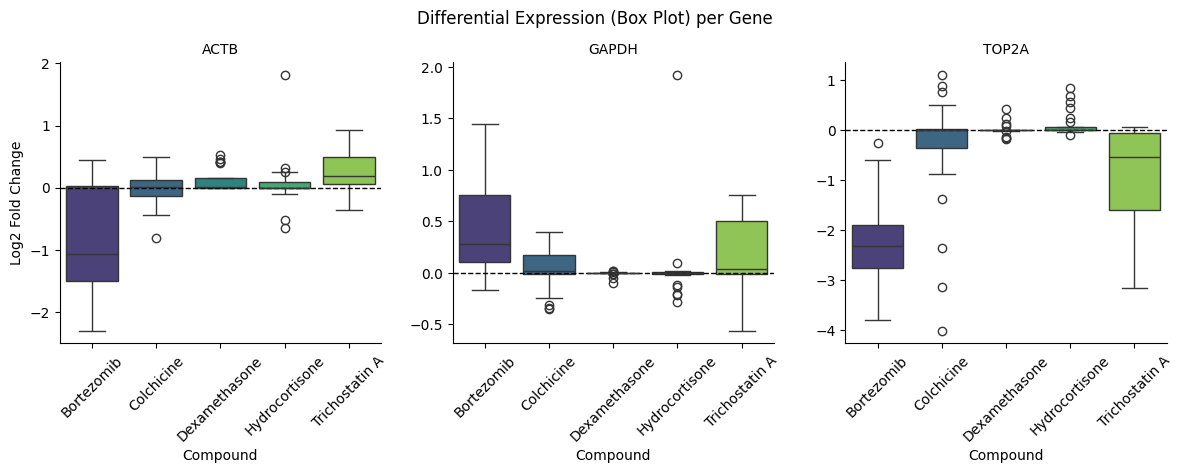

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a Faceted Plot with Box Plots
g = sns.FacetGrid(df_genes, col="gene", col_wrap=3, height=4, sharey=False)

# Change 'sns.barplot' to 'sns.boxplot'
g.map_dataframe(sns.boxplot, x="compound", y="log2FoldChange", palette="viridis", hue="compound")

g.set_axis_labels("Compound", "Log2 Fold Change")
g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.tick_params(axis='x', rotation=45)

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Differential Expression (Box Plot) per Gene')
plt.show()

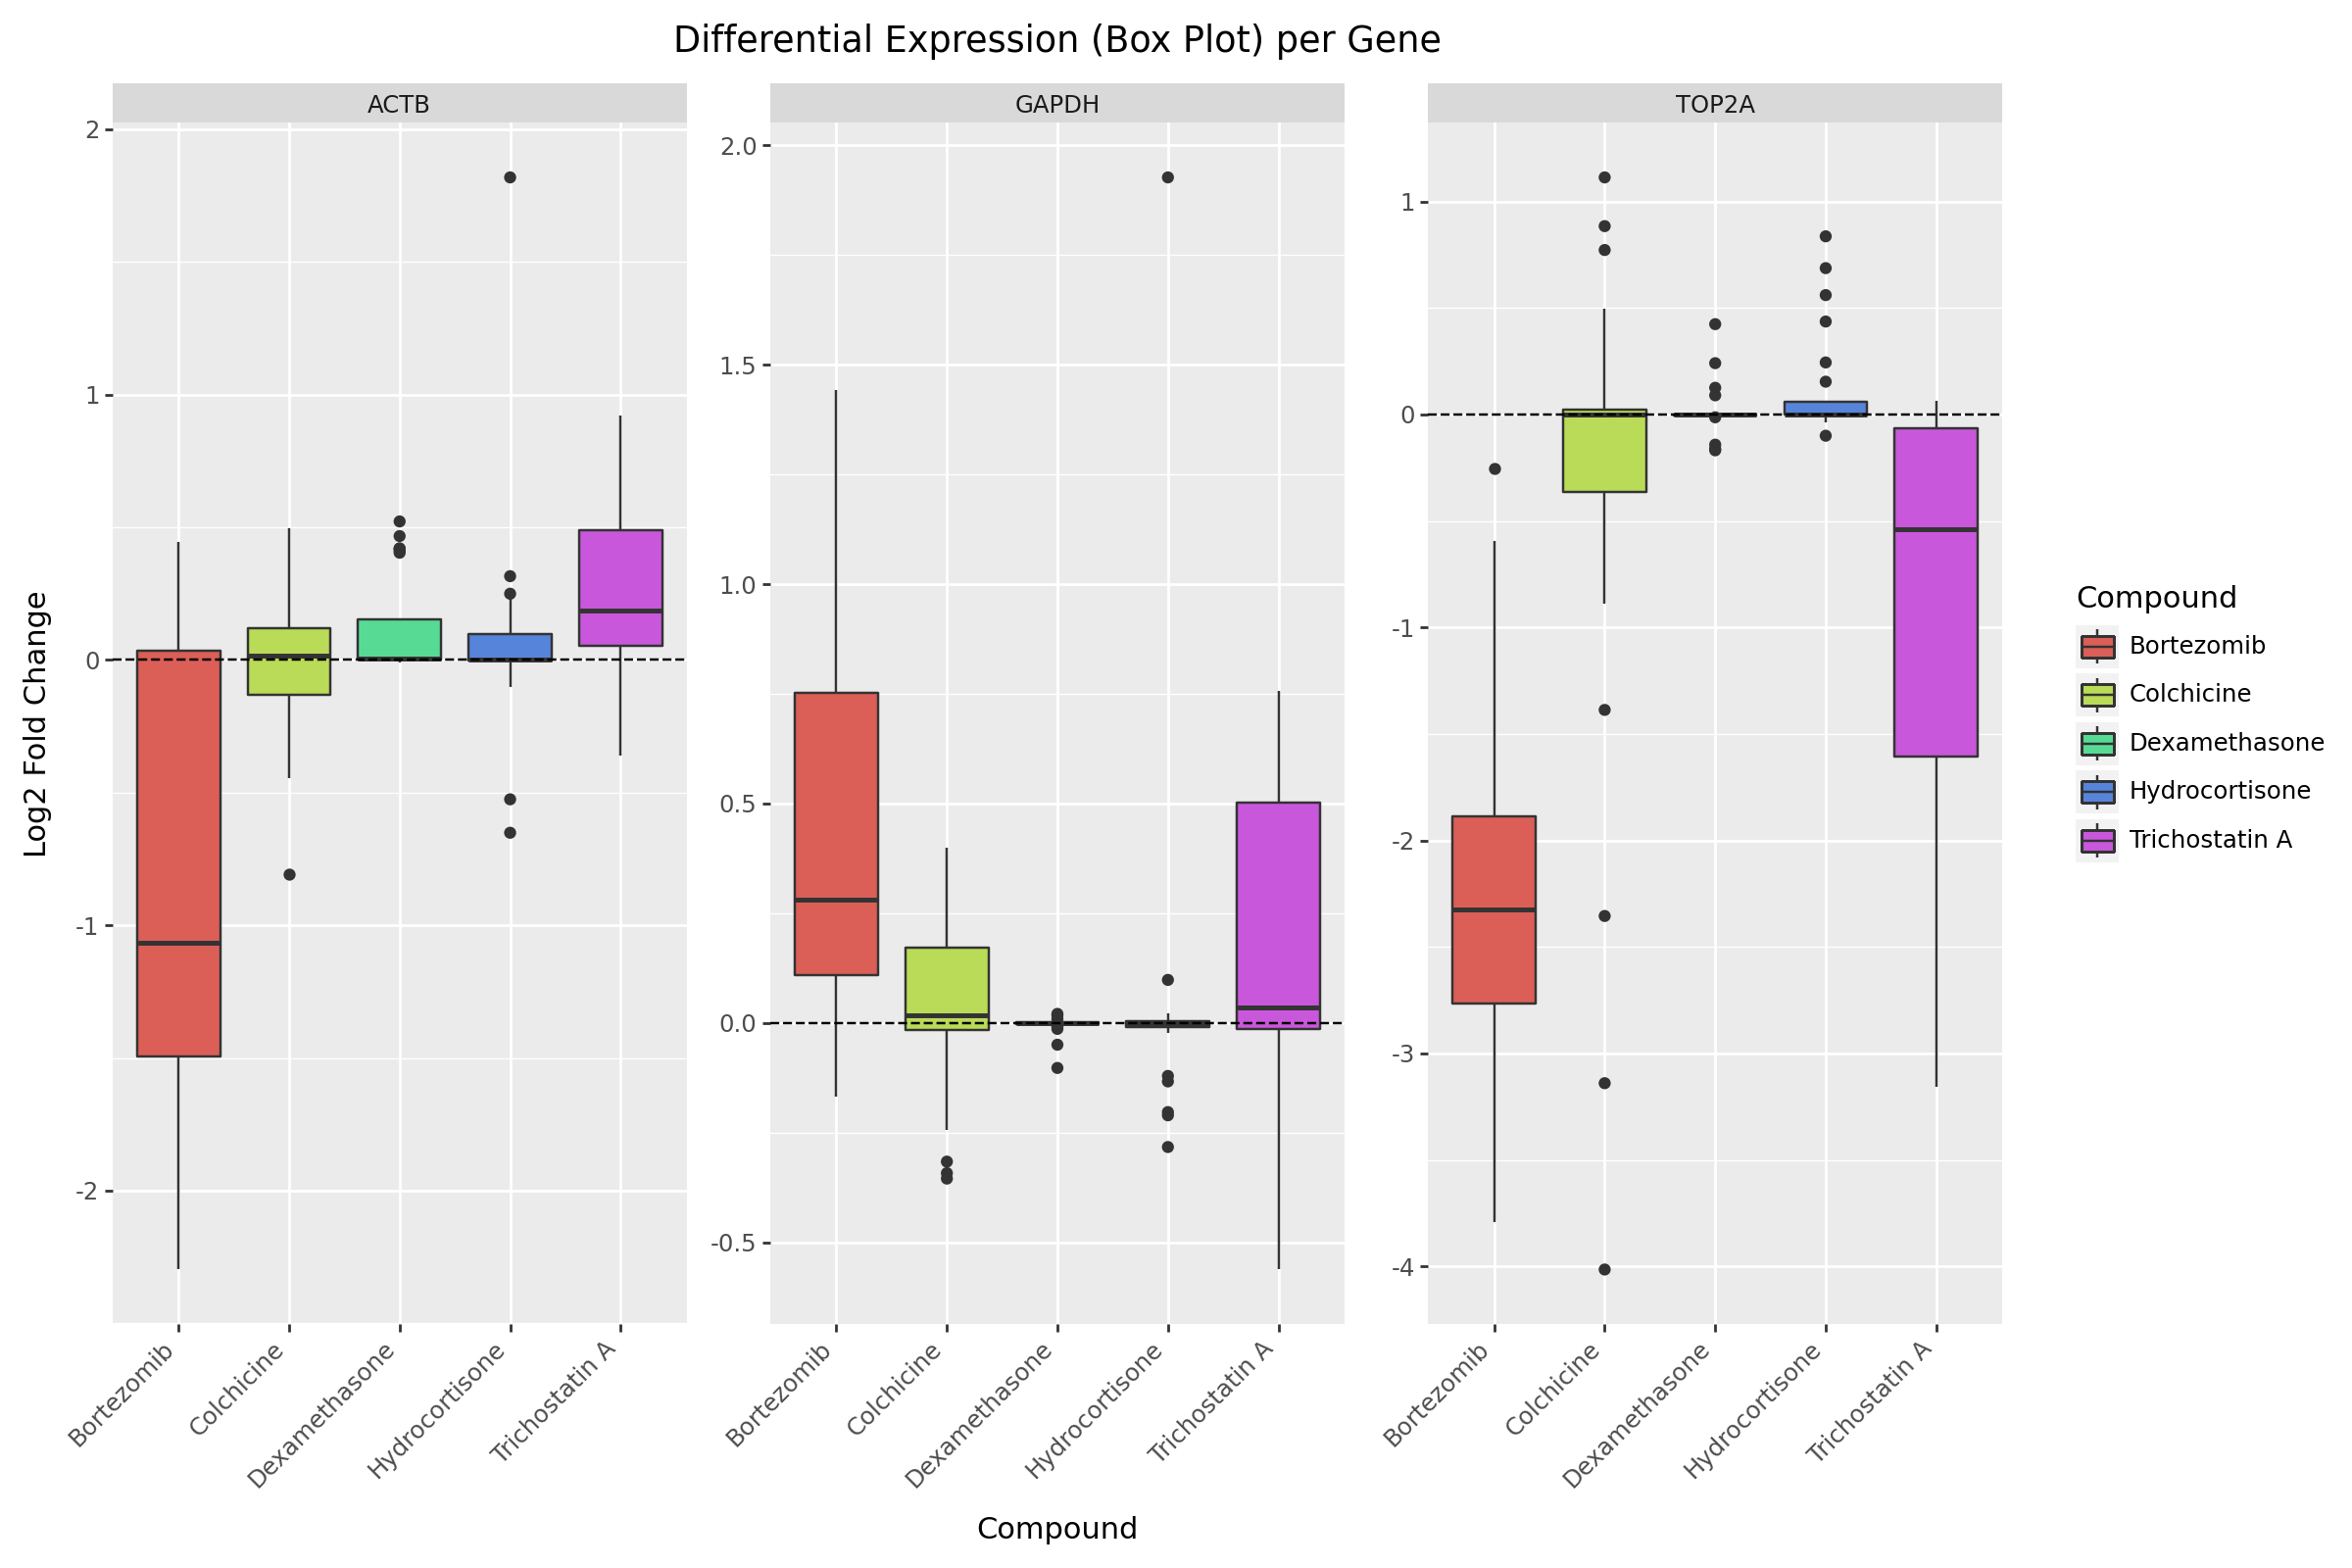

In [9]:
from plotnine import ggplot, aes, geom_boxplot, facet_wrap, geom_hline, theme, element_text, labs

# 1. Create the plot
plot = (
    ggplot(df_genes, aes(x='compound', y='log2FoldChange', fill='compound'))
    + geom_boxplot()

    # 2. Add faceting (equivalent to col_wrap=3 and sharey=False)
    + facet_wrap('~gene', ncol=3, scales='free_y')

    # 3. Add the horizontal line at 0
    + geom_hline(yintercept=0, linetype='dashed', color='black', size=0.5)

    # 4. Labels and Title
    + labs(
        x='Compound',
        y='Log2 Fold Change',
        title='Differential Expression (Box Plot) per Gene',
        fill='Compound'
    )

    # 5. Styling (Rotation and spacing)
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1),
        figure_size=(12, 8) # Adjust height/width as needed
    )
)

plot

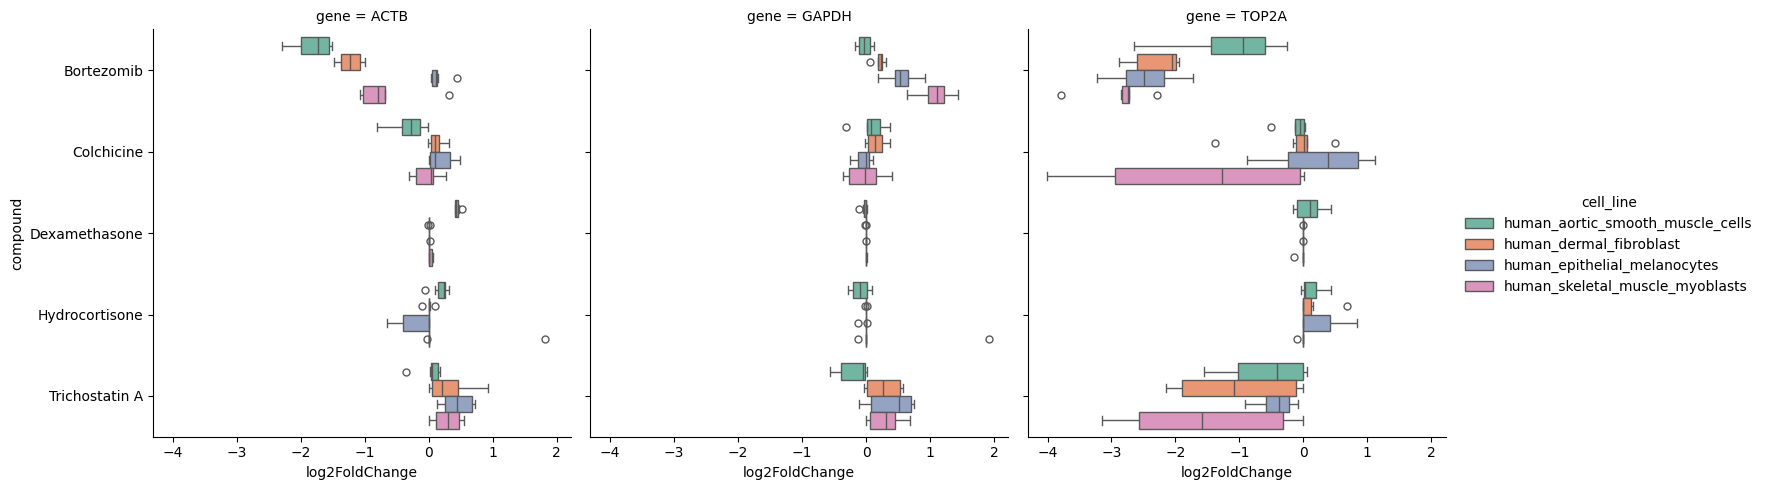

In [10]:
# CODE FOR "DRUG DISCOVERY" VIEW
sns.catplot(
    data=df_genes,
    col="gene",           # Separate panels for ACTB, GAPDH, TOP2A
    y="compound",         # List drugs vertically for ranking
    x="log2FoldChange",   # Magnitude of effect
    hue="cell_line",      # Check consistency across tissues
    kind="box",
    palette="Set2",
    sharex=True           # Keep scales same to compare potency
)

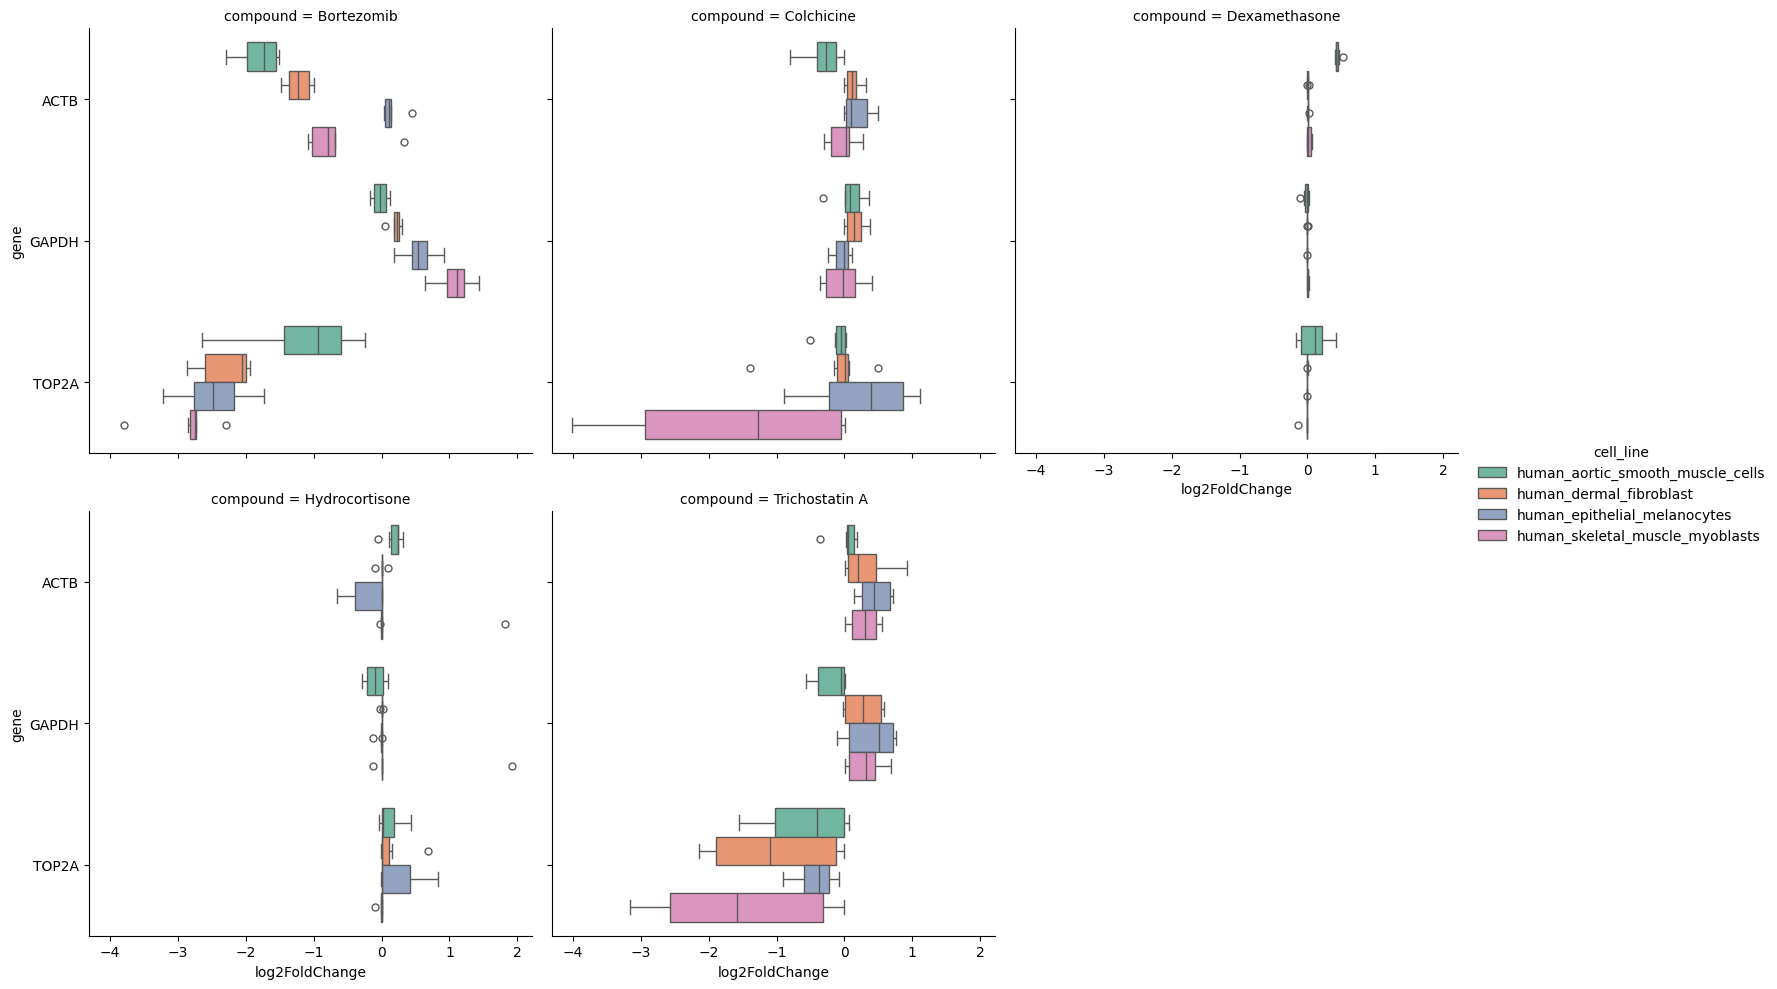

In [11]:
# CODE FOR "MECHANISM OF ACTION" VIEW
sns.catplot(
    data=df_genes,
    col="compound",       # Separate panel for each drug
    col_wrap=3,           # Wrap so it doesn't get too wide
    y="gene",             # List genes to show the "fingerprint"
    x="log2FoldChange",
    hue="cell_line",
    kind="box",
    palette="Set2"
)

# 4. View A: Drug Discovery Profile (Loop per Cell Line):
This generates 4 separate grids (one per tissue) to rank drug potency.

/tmp/ipython-input-239041175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipython-input-239041175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipython-input-239041175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipython-input-239041175.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



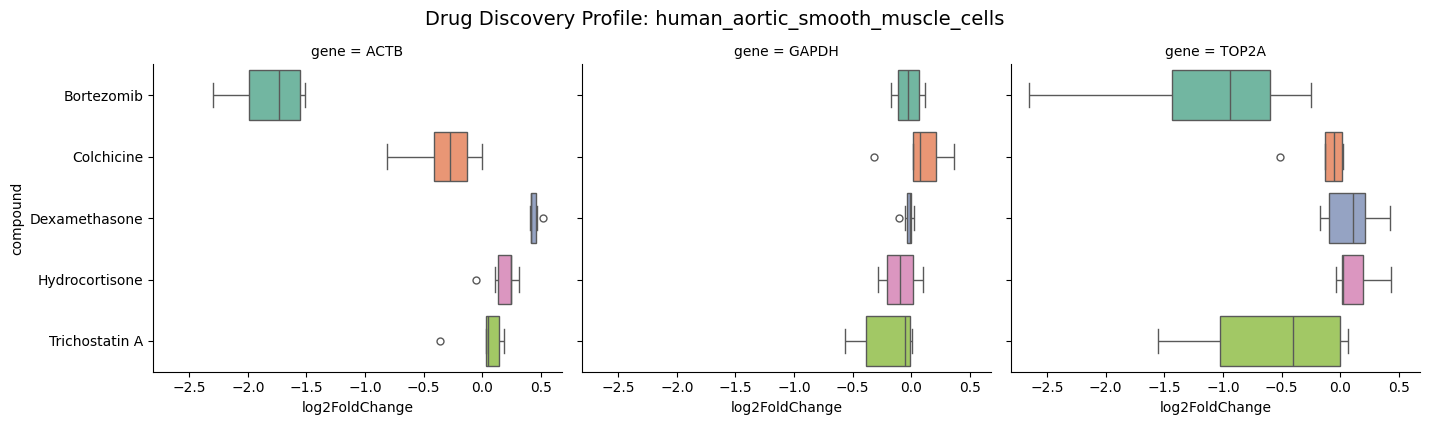

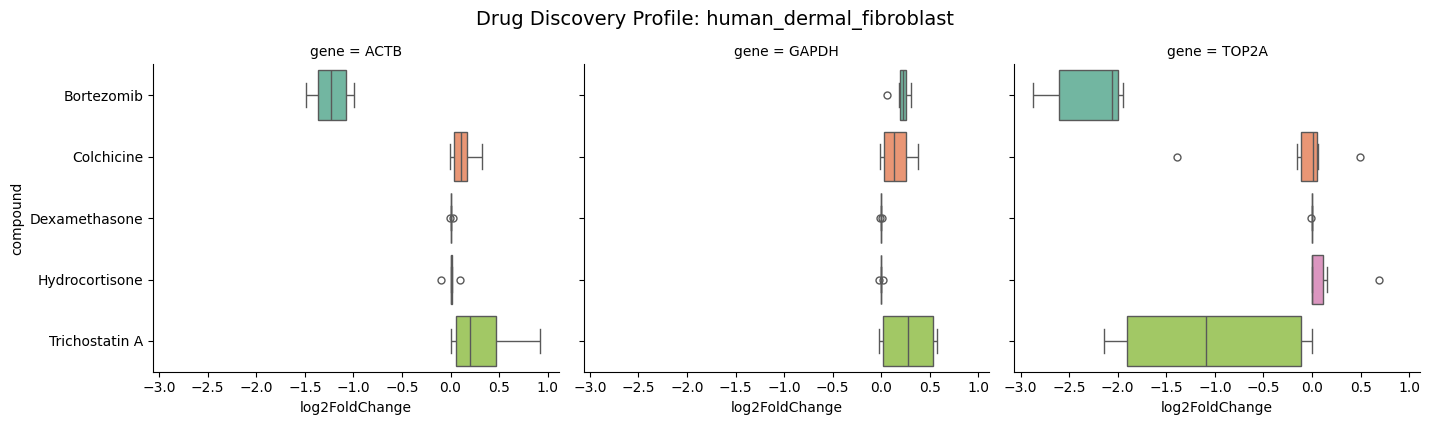

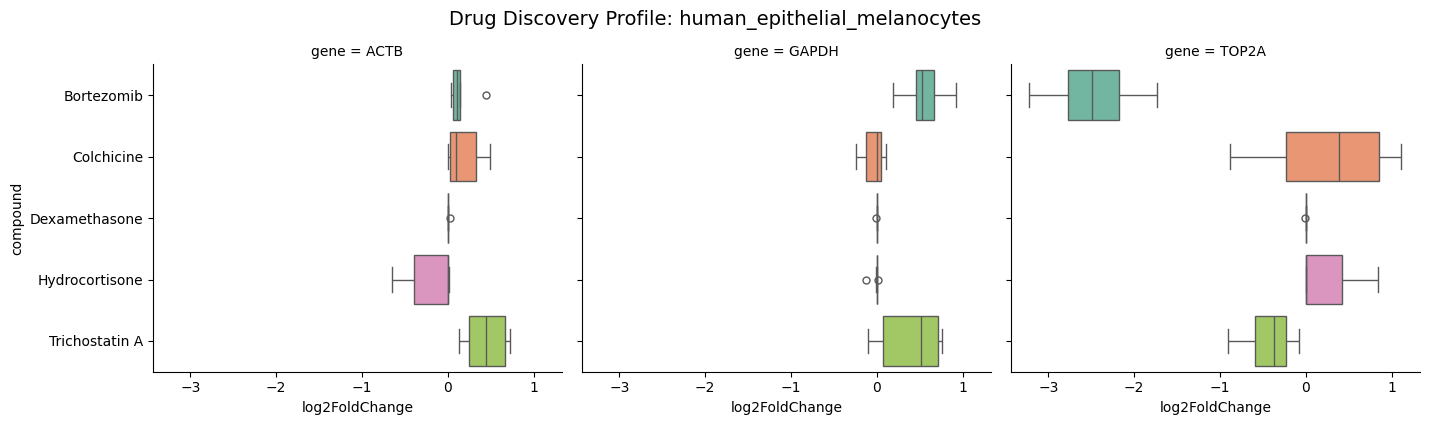

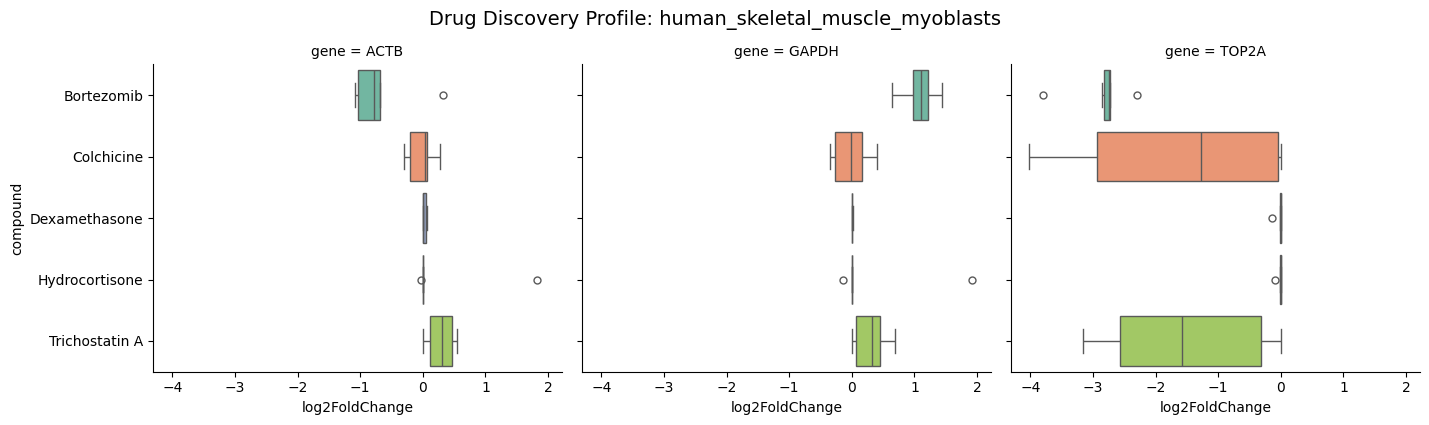

In [12]:
# List of unique cell lines in your data
cell_lines = df_genes['cell_line'].unique()

for cell in cell_lines:
    # Filter the data for the specific cell line
    df_subset = df_genes[df_genes['cell_line'] == cell]

    # Create the catplot for this specific cell line
    g = sns.catplot(
        data=df_subset,
        col="gene",
        y="compound",
        x="log2FoldChange",
        kind="box",
        palette="Set2",
        sharex=True,
        height=4,
        aspect=1.2
    )

    # Add a title to each figure to identify the cell line
    g.fig.suptitle(f"Drug Discovery Profile: {cell}", y=1.05, fontsize=14)

# 5. View B: Mechanism of Action (Drug Fingerprints)
This shows how each drug affects the three genes within a specific tissue.

/tmp/ipython-input-1906404991.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipython-input-1906404991.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipython-input-1906404991.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

/tmp/ipython-input-1906404991.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



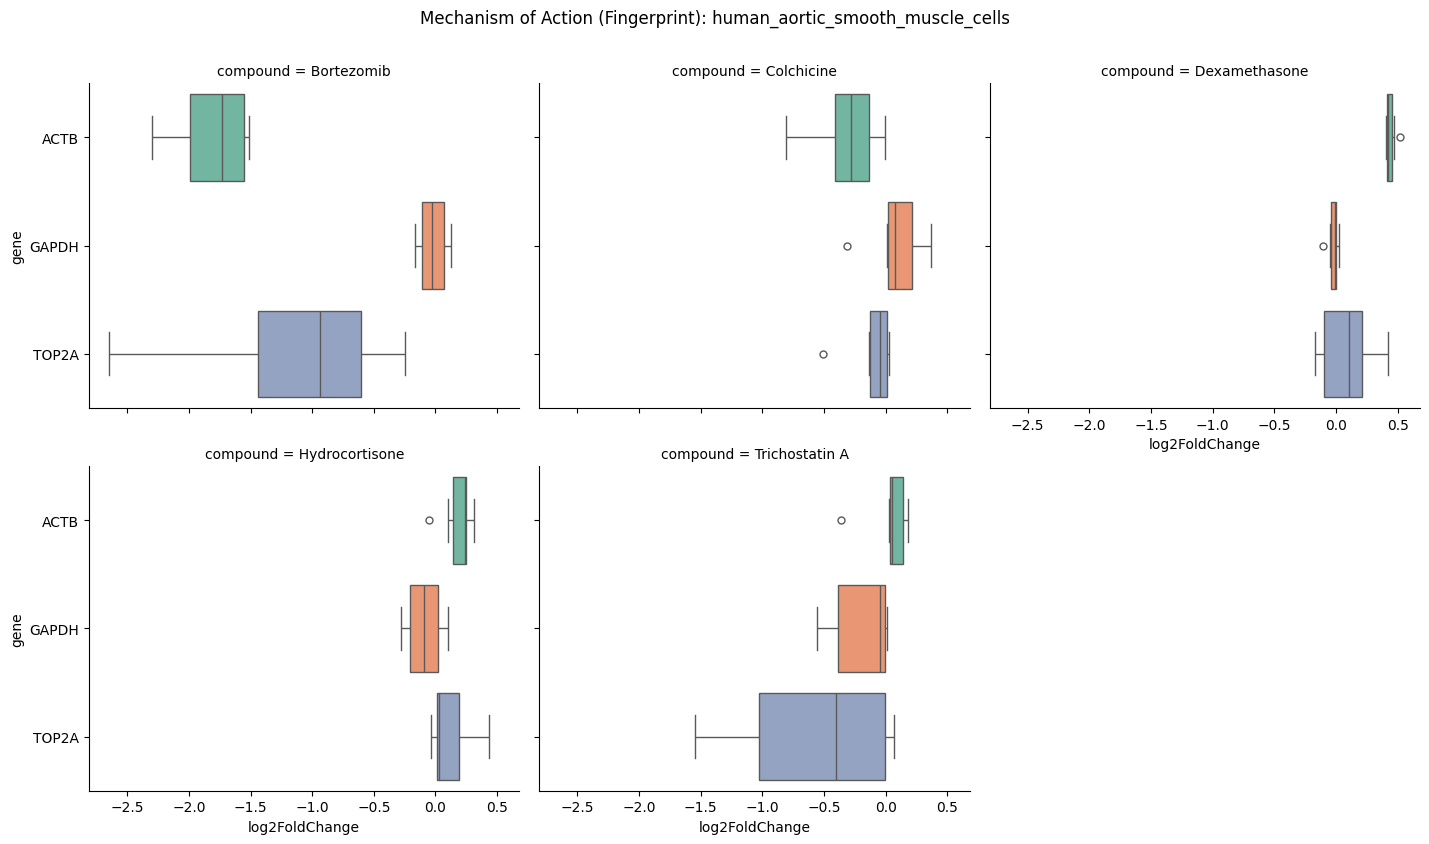

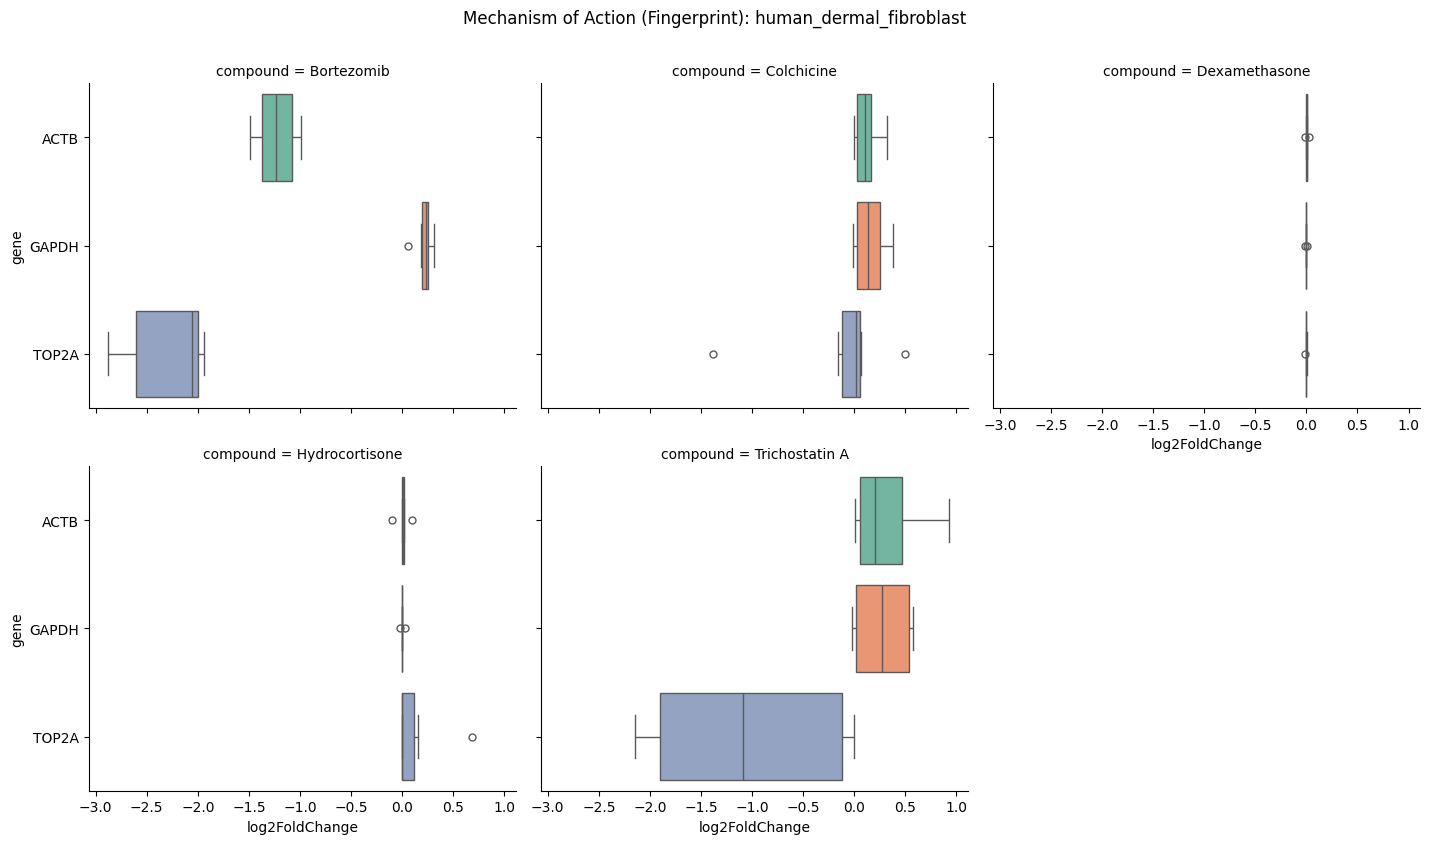

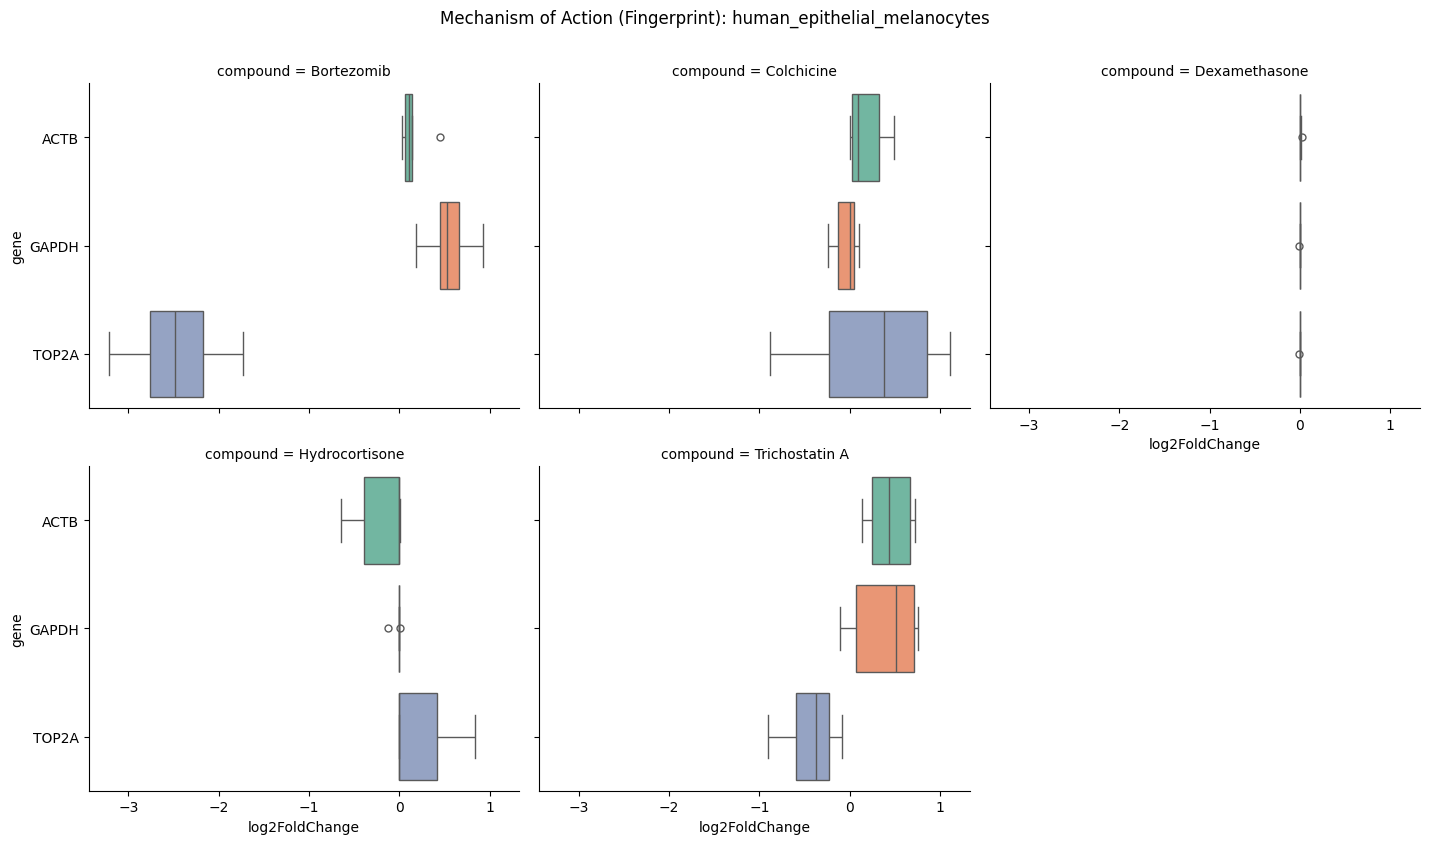

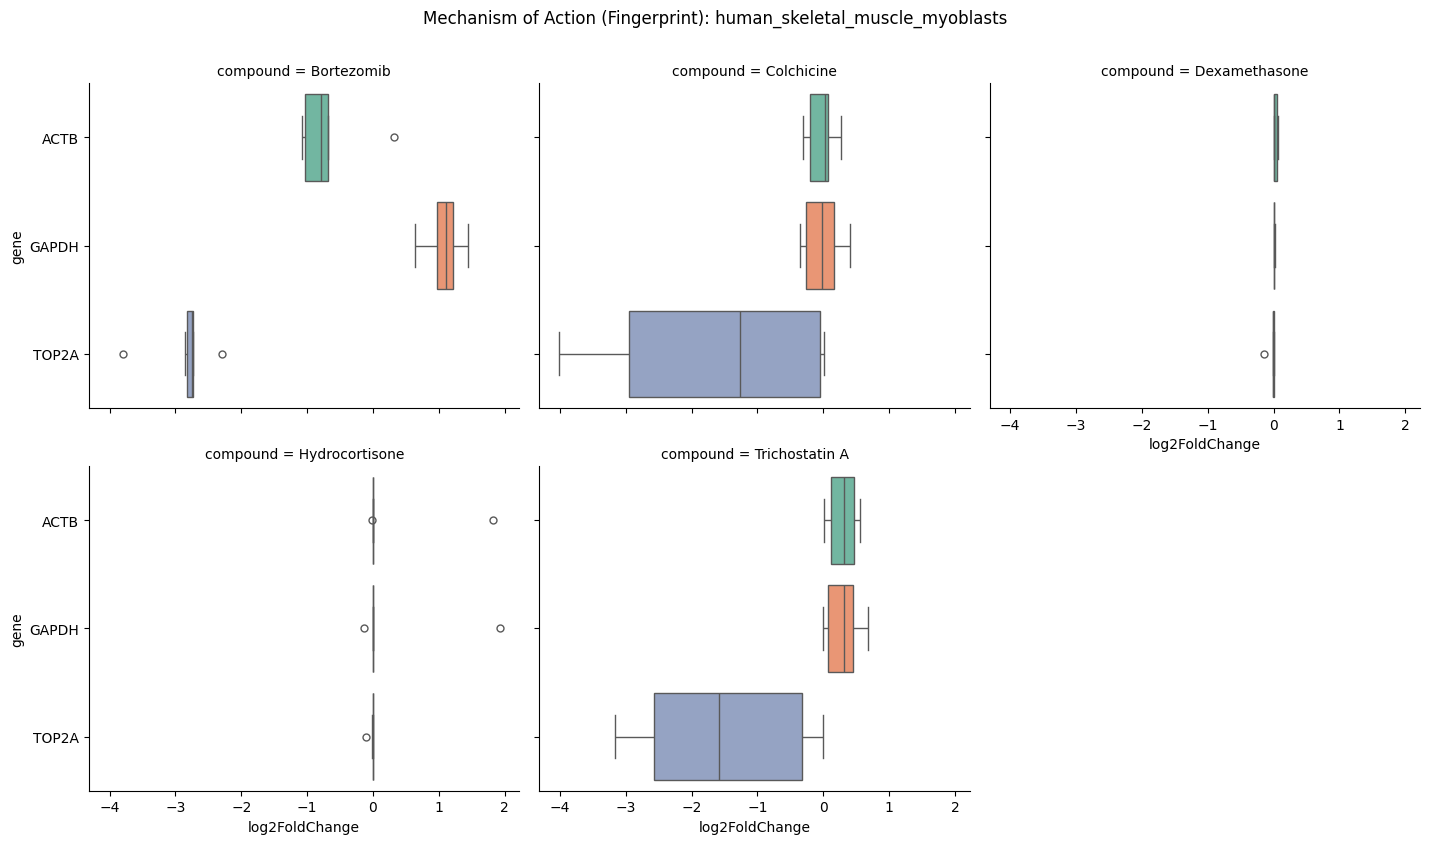

In [13]:
for cell in cell_lines:
    df_subset = df_genes[df_genes['cell_line'] == cell]

    # Mechanism of Action View
    g = sns.catplot(
        data=df_subset,
        col="compound",
        col_wrap=3,
        y="gene",
        x="log2FoldChange",
        kind="box",
        palette="Set2",
        height=4,
        aspect=1.2
    )
    g.fig.suptitle(f"Mechanism of Action (Fingerprint): {cell}", y=1.05)

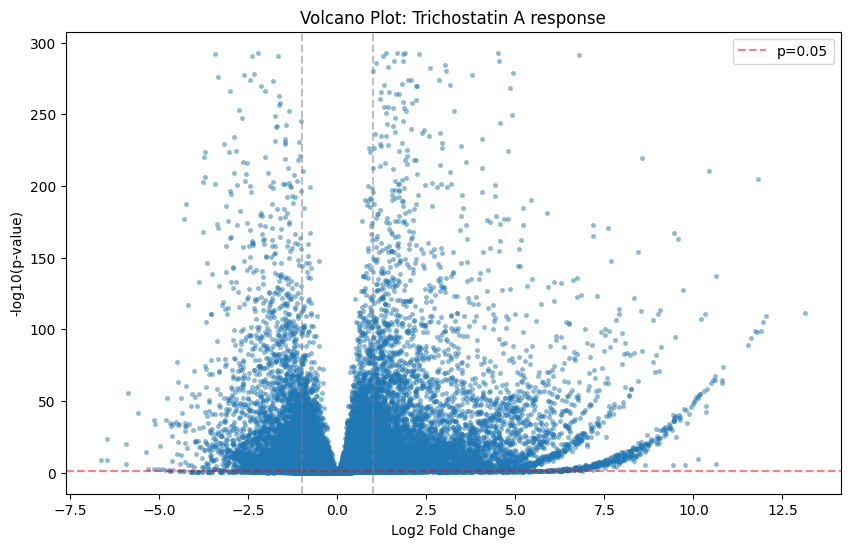

In [14]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Filter for a specific condition (e.g., Trichostatin A in one cell line)
# Volcano plots usually look at one treatment vs control at a time
condition_df = (
    df_pl.lazy()
    .filter(
        (pl.col("compound") == "Trichostatin A") &
        (pl.col("cell_line") == "human_skeletal_muscle_myoblasts") # Replace with a cell line from your list
    )
    .with_columns([
        # Calculate -log10(pvalue) for the Y-axis
        (pl.col("pvalue").log(10) * -1).alias("neg_log10_p")
    ])
    .collect()
)

# 2. Create the plot
plt.figure(figsize=(10, 6))

# Use a scatter plot for the thousands of genes in this condition
sns.scatterplot(
    data=condition_df.to_pandas(),
    x="log2FoldChange",
    y="neg_log10_p",
    alpha=0.5,
    edgecolor=None,
    s=10
)

# 3. Add significance thresholds
plt.axhline(-np.log10(0.05), color='red', linestyle='--', alpha=0.5, label='p=0.05') # Significance line
plt.axvline(1, color='gray', linestyle='--', alpha=0.5) # 2-fold up
plt.axvline(-1, color='gray', linestyle='--', alpha=0.5) # 2-fold down

plt.title("Volcano Plot: Trichostatin A response")
plt.xlabel("Log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.legend()
plt.show()

In [22]:
# Use Pandas pivot_table correctly
pivot_df = df_genes.pivot_table(
    values="log2FoldChange",
    index=["cell_line", "compound"],
    columns="gene",     # Changed 'on' to 'columns'
    aggfunc="mean"
).fillna(0).reset_index()

print(f"Pivot complete. Shape: {pivot_df.shape}")

Pivot complete. Shape: (20, 5)


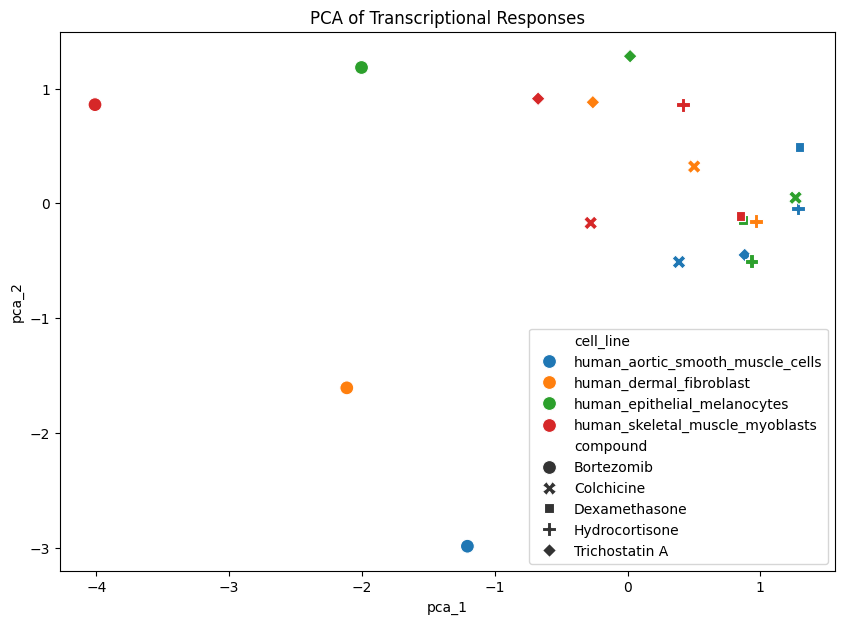

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Extract the features (the gene expression values)
# Use Pandas .drop() instead of Polars .select()
features = pivot_df.drop(columns=["cell_line", "compound"]).values

# 2. Extract the metadata for plotting labels later
# In Pandas, metadata is already a subset of the DataFrame
metadata = pivot_df[["cell_line", "compound"]].copy()

# 3. Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 4. Run PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_features)

# 5. Add results back to metadata for plotting
metadata['pca_1'] = pca_results[:, 0]
metadata['pca_2'] = pca_results[:, 1]

# 6. Plot the results
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=metadata,
    x='pca_1',
    y='pca_2',
    hue='cell_line',
    style='compound',
    s=100
)
plt.title("PCA of Transcriptional Responses")
plt.show()

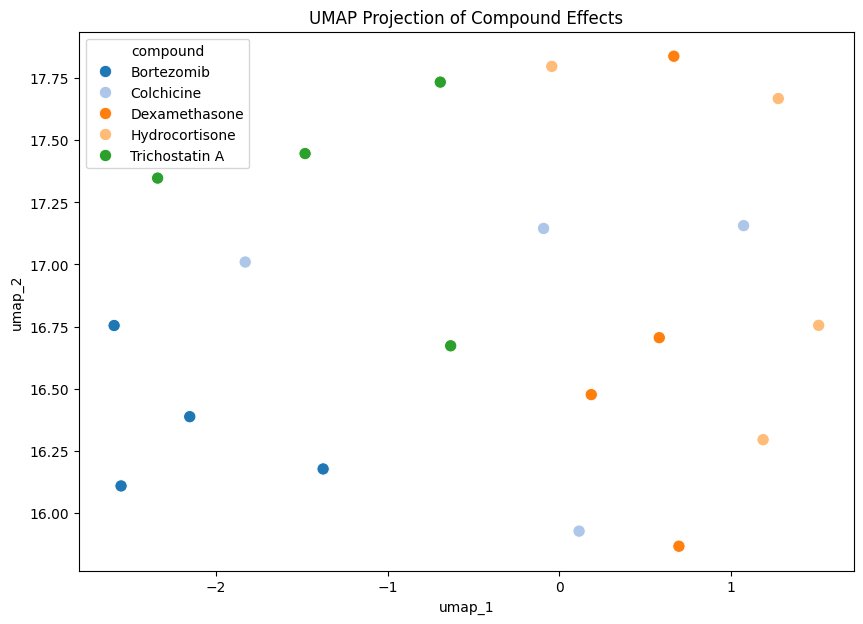

In [25]:
import umap

# Initialize and fit UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean')
embedding = reducer.fit_transform(features)

metadata['umap_1'] = embedding[:, 0]
metadata['umap_2'] = embedding[:, 1]

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=metadata, x='umap_1', y='umap_2', hue='compound', palette='tab20', s=80)
plt.title("UMAP Projection of Compound Effects")
plt.show()